# Quantum Metric Learning

This notebook demonstrates supervised **quantum metric learning** using a
trainable embedding circuit.

The embedding parameters are optimised using a **contrastive loss**:

- same-class samples are pulled closer together
- different-class samples are pushed apart

Classification is performed using a **nearest-centroid rule** in the learned
quantum feature space.

The notebook is a thin client that calls into the `qml` package.

In [1]:
from qml.metric_learning import run_quantum_metric_learner

[metric_learning] step=0001 loss=0.427937
[metric_learning] step=0010 loss=0.305071
[metric_learning] step=0020 loss=0.298624
[metric_learning] step=0030 loss=0.255549
[metric_learning] step=0040 loss=0.286283
[metric_learning] step=0050 loss=0.260128
[metric_learning] step=0060 loss=0.143402
[metric_learning] step=0070 loss=0.156889
[metric_learning] step=0075 loss=0.098516


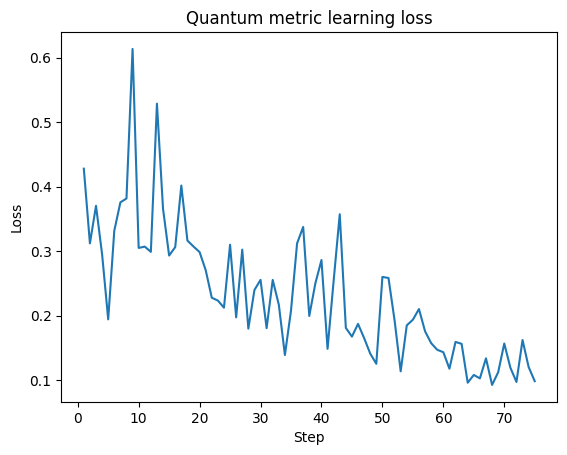

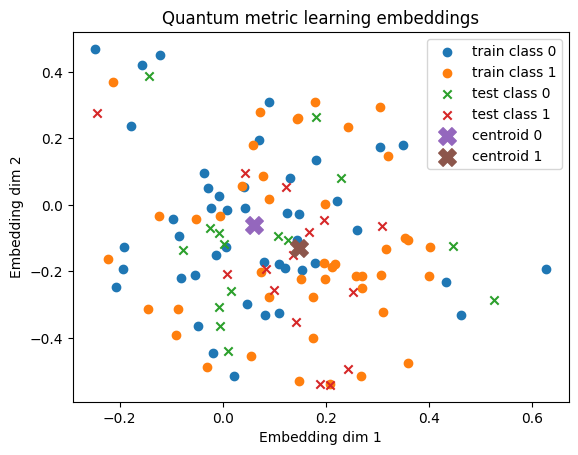

Train accuracy: 0.6111111111111112
Test accuracy: 0.6
Final loss: 0.09851639525405846


In [ ]:
result = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=2,
    steps=75,
    stepsize=0.05,
    margin=0.5,
    pairs_per_step=32,
    seed=123,
    plot=True,
)

print("Train accuracy:", result.train_accuracy)
print("Test accuracy:", result.test_accuracy)
print("Final loss:", result.loss_history[-1])

In [3]:
# Inspect embedding outputs

print("Train embedding shape:", result.train_embeddings.shape)
print("Test embedding shape:", result.test_embeddings.shape)

Train embedding shape: (90, 2)
Test embedding shape: (30, 2)


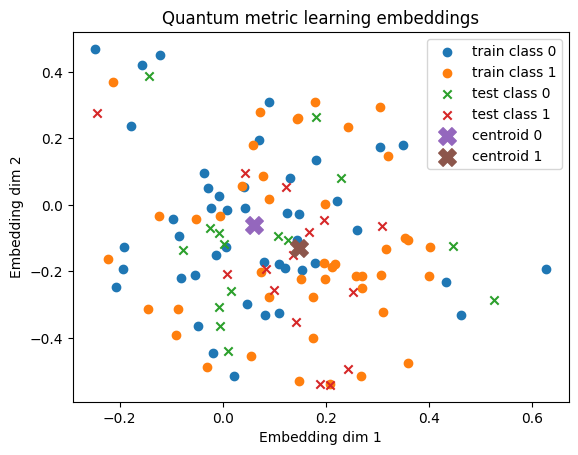

In [4]:
from qml.visualize import plot_metric_learning_embeddings

plot_metric_learning_embeddings(
    train_embeddings=result.train_embeddings,
    y_train=result.y_train,
    test_embeddings=result.test_embeddings,
    y_test=result.y_test,
    centroids=result.train_centroids,
)

In [5]:
# Hyperparameter variation

result_small = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=1,
    steps=75,
    pairs_per_step=16,
    seed=123,
)

print("layers=1 test accuracy:", result_small.test_accuracy)

[metric_learning] step=0001 loss=0.087691


[metric_learning] step=0010 loss=0.225662
[metric_learning] step=0020 loss=0.134055
[metric_learning] step=0030 loss=0.130827
[metric_learning] step=0040 loss=0.144779
[metric_learning] step=0050 loss=0.261926
[metric_learning] step=0060 loss=0.167996
[metric_learning] step=0070 loss=0.194980
[metric_learning] step=0075 loss=0.151230
layers=1 test accuracy: 0.7


In [6]:
# Compare dataset choices

for dataset in ["moons", "circles", "blobs"]:

    res = run_quantum_metric_learner(
        dataset=dataset,
        samples=120,
        layers=2,
        steps=75,
        seed=123,
    )

    print()
    print(dataset)
    print("  train accuracy:", res.train_accuracy)
    print("  test accuracy:", res.test_accuracy)

[metric_learning] step=0001 loss=0.427937
[metric_learning] step=0010 loss=0.305071
[metric_learning] step=0020 loss=0.298624
[metric_learning] step=0030 loss=0.255549
[metric_learning] step=0040 loss=0.286283
[metric_learning] step=0050 loss=0.260128
[metric_learning] step=0060 loss=0.143402
[metric_learning] step=0070 loss=0.156889
[metric_learning] step=0075 loss=0.098516

moons
  train accuracy: 0.6111111111111112
  test accuracy: 0.6
[metric_learning] step=0001 loss=0.356441
[metric_learning] step=0010 loss=0.428865
[metric_learning] step=0020 loss=0.303805
[metric_learning] step=0030 loss=0.204626
[metric_learning] step=0040 loss=0.247740
[metric_learning] step=0050 loss=0.143872
[metric_learning] step=0060 loss=0.121123
[metric_learning] step=0070 loss=0.149328
[metric_learning] step=0075 loss=0.112340

circles
  train accuracy: 0.7222222222222222
  test accuracy: 0.6333333333333333
[metric_learning] step=0001 loss=0.140471
[metric_learning] step=0010 loss=0.056122
[metric_learn